<a href="https://colab.research.google.com/github/Hiraz-cipher/D-B-Assignment/blob/main/SQL_in_R_(Part_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Packages

In [3]:
install.packages("sqldf", repos='http://cran.us.r-project.org')
install.packages("dplyr", repos='http://cran.us.r-project.org')
install.packages("readr", repos='http://cran.us.r-project.org')
install.packages("ggplot2", repos='http://cran.us.r-project.org')
install.packages("lubridate", repos='http://cran.us.r-project.org')
install.packages("readxl", repos='http://cran.us.r-project.org')

library(sqldf)
library(dplyr)
library(readr)
library(ggplot2)
library(lubridate)
library(readxl)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are mask

Data Loading

In [7]:
library(readr)

customers  <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/customers.csv")
orders     <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/orders.csv")
deliveries <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/deliveries.csv")
complaints <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/complaints.csv")
drivers    <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/drivers.csv")
vehicles   <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/vehicles.csv")
hubs       <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/hubs.csv")
incidents  <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/incidents.csv")
app_events <- read_csv("https://raw.githubusercontent.com/Hiraz-cipher/D-B-Assignment/main/app_events.csv" )


cat("customers:", nrow(customers), "rows\n")
head(customers)
cat("orders:", nrow(orders), "rows\n")
head(orders)
cat("deliveries:", nrow(deliveries), "rows\n")
head(deliveries)
cat("complaints:", nrow(complaints), "rows\n")
head(complaints)
cat("drivers:", nrow(drivers), "rows\n")
head(drivers)
cat("vehicles:", nrow(vehicles), "rows\n")
head(vehicles)
cat("hubs:", nrow(hubs),"rows\n")
head(hubs)
cat("incidents:", nrow(incidents),"rows\n")
head(incidents)
cat("app_events:", nrow(app_events), "rows\n")
head(app_events)

print("Inserting of csv files are done")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6)

customers: 650 rows


customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


orders: 1250 rows


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


...

incidents: 280 rows


incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
<chr>,<chr>,<chr>,<dttm>,<chr>,<chr>,<dbl>
I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0
I0006,DL00634,CustomerNoShow,2025-08-08 21:26:00,High,PendingVendor,19.9


app_events: 640 rows


event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
<chr>,<chr>,<chr>,<dttm>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AE00001,C0488,NA,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
AE00005,C0506,NA,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1
AE00006,C0498,O01196,2025-02-08 09:50:00,track_order,S66655,Web,West,499,1


[1] "Inserting of csv files are done"


In [ ]:
Data Cleaning

In [11]:
clean_zone <- function(z) {
  z <- toupper(trimws(z))
  z <- ifelse(z == "CTR", "CENTRAL", z)
  z <- ifelse(z == "RIVERSIDE", "RIVERSIDE", z)
  return(z)
}

customers$home_zone   <- clean_zone(customers$home_zone)
drivers$base_zone     <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
orders$pickup_zone    <- clean_zone(orders$pickup_zone)
orders$dropoff_zone   <- clean_zone(orders$dropoff_zone)
hubs$zone             <- clean_zone(hubs$zone)

cat("Zone cleaning complete. Unique zones in customers:\n")
print(table(customers$home_zone))

Zone cleaning complete. Unique zones in customers:

  AIRPORT   CENTRAL      EAST     NORTH RIVERSIDE     SOUTH      WEST 
       69       110        89       111        91        92        88 


Query 1: Hub Performance

In [ ]:
query1 <- sqldf("
SELECT
  hub_id,
  Count(*) AS total_deliveries,
  SUM(CASE WHEN delivery_status = 'onTime' Then 1 ELSE 0 END) AS on_time,
  SUM(CASE WHEN delivery_status = 'Delayed' Then 1 ElSE 0 END) AS delayed,
  SUM(CASE WHEN delivery_status = 'Failed' Then 1 Else 0 END) AS failed,
  ROUND(AVG(customer_rating_post_delivery),2) AS avg_rating
  FROM deliveries
  GROUP BY hub_id
  ORDER BY failed DESC
")
print(query1)
# WRITE IN REPORT:
# Which hub has the most failures?
# Is there a link between high failures and low customer ratings

  hub_id total_deliveries on_time delayed failed avg_rating
1    H08              128       0      22     26       3.88
2    H05              115       0      25     23       3.67
3    H01              136       0      26     17       3.84
4    H04              127       0      28     16       3.92
5    H06              104       0      27     15       3.88
6    H07              115       0      25     14       3.88
7    H03              119       0      23     11       3.90
8    H02              106       0      26     10       3.95


Query 2 - Complaints by Service Type

In [ ]:
library(sqldf)
# This joins orders and complaints to see which service type gets most complaints

query2 <- sqldf("
  SELECT
    o.service_type,
    COUNT(o.order_id) AS total_orders,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.resolution_days), 1) AS avg_days_to_resolve
  FROM orders o
  LEFT JOIN complaints c ON o.order_id = c.order_id
  GROUP BY o.service_type
  ORDER BY total_complaints DESC
")

print(query2)

# WRITE IN REPORT:
# Which service type has the most complaints?
# Are complaints being resolved quickly or slowly?

  service_type total_orders total_complaints avg_days_to_resolve
1    Passenger          348               84                 7.7
2       Retail          308               83                 7.9
3       Parcel          316               77                 8.3
4     Business          170               39                 7.9
5      Medical          143               37                 7.6


Query 3 — Driver Performance

In [ ]:
query3 <- sqldf("
  SELECT
    d.driver_id,
    d.employment_type,
    d.training_score,
    d.driver_rating,
    COUNT(dl.delivery_id) AS total_deliveries,
    SUM(CASE WHEN dl.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    SUM(dl.manual_route_override_count) AS total_overrides
  FROM drivers d
  LEFT JOIN deliveries dl ON d.driver_id = dl.driver_id
  GROUP BY d.driver_id, d.employment_type, d.training_score, d.driver_rating
  ORDER BY failed_deliveries DESC
  LIMIT 10
")

print(query3)

   driver_id employment_type training_score driver_rating total_deliveries
1       D024        PartTime           71.4          3.35                8
2       D104        FullTime           87.7          3.45                7
3       D133        Contract           88.2          3.99               12
4       D004        PartTime           88.9          4.75                9
5       D010        FullTime           70.0          3.95                7
6       D055        FullTime           90.5          5.00               10
7       D083        FullTime           80.8          4.16                9
8       D092        FullTime           88.2          4.24                5
9       D108        FullTime           70.6          4.33               11
10      D131        FullTime           86.7          4.26                9
   failed_deliveries total_overrides
1                  4               9
2                  4              12
3                  4              11
4                  3       

Query 4 - Vehicle Maintenance vs Incidents

In [ ]:

query4 <- sqldf("
  SELECT
    v.vehicle_id,
    v.vehicle_type,
    v.maintenance_status,
    v.battery_health_pct,
    v.odometer_km,
    COUNT(DISTINCT dl.delivery_id) AS deliveries_done,
    COUNT(DISTINCT i.incident_id)  AS total_incidents,
    SUM(CASE WHEN i.incident_type = 'BatteryAlert'  THEN 1 ELSE 0 END) AS battery_alerts,
    SUM(CASE WHEN i.incident_type = 'VehicleFault'  THEN 1 ELSE 0 END) AS vehicle_faults
  FROM vehicles v
  LEFT JOIN deliveries dl ON v.vehicle_id   = dl.vehicle_id
  LEFT JOIN incidents  i  ON dl.delivery_id = i.delivery_id
  GROUP BY v.vehicle_id, v.vehicle_type, v.maintenance_status,
           v.battery_health_pct, v.odometer_km
  ORDER BY total_incidents DESC
  LIMIT 10
")

print(query4)

# WRITE IN REPORT:
# Vehicles with InRepair status or low battery_health_pct likely
# have more BatteryAlert and VehicleFault incidents.
# This shows NorthStar needs proactive maintenance scheduling.

   vehicle_id vehicle_type maintenance_status battery_health_pct odometer_km
1        V047           EV          Scheduled               93.7      134347
2        V108       Diesel           InRepair               54.6      141290
3        V030     CargoVan             Active               78.0      134360
4        V046           EV             Active               95.8      101425
5        V097           EV             Active               92.1       18680
6        V005     CargoVan             Active               58.6      146638
7        V009     CargoVan             Active               68.8      156687
8        V035     CargoVan             Active               83.6       73804
9        V042           EV           InRepair               80.5      215870
10       V076       Diesel           InRepair               65.8      106063
   deliveries_done total_incidents battery_alerts vehicle_faults
1               17               9              0              2
2                9     

Query 5 -  App Events by Failure

In [ ]:

query5 <- sqldf("
  SELECT
    ae.event_type,
    ae.device_type,
    cu.customer_type,
    COUNT(*) AS failed_events,
    ROUND(AVG(ae.api_latency_ms), 0) AS avg_latency_ms
  FROM (
    SELECT * FROM app_events WHERE success_flag = 0
  ) AS ae
  LEFT JOIN orders    o  ON ae.order_id    = o.order_id
  LEFT JOIN customers cu ON ae.customer_id = cu.customer_id
  GROUP BY ae.event_type, ae.device_type, cu.customer_type
  ORDER BY failed_events DESC
  LIMIT 15
")

print(query5)

# WRITE IN REPORT:
# The subquery filters only failed app events before joining.
# This is more efficient because we join a smaller table
# instead of joining everything and then filtering.


       event_type device_type customer_type failed_events avg_latency_ms
1   payment_retry     Android      Consumer            10            470
2   payment_retry         iOS      Consumer             6            373
3  chat_escalated     Android      Consumer             5            553
4  chat_escalated     Android           SME             4            394
5  chat_escalated         iOS      Consumer             4            602
6  chat_escalated         Web      Consumer             3            735
7  chat_escalated     Android    Enterprise             1            137
8  chat_escalated         Web    Enterprise             1            399
9  chat_escalated         Web           SME             1            235
10  payment_retry     Android    Enterprise             1            567
11  payment_retry         Web      Consumer             1             60
12  payment_retry         iOS           SME             1            516


Query 6 - Incident Resolution Status by Type

      incident_type resolution_status incident_count
1      ProofMissing            Closed             24
2    CustomerNoShow            Closed             21
3    RouteDeviation            Closed             18
4      BatteryAlert            Closed             16
5  TemperatureIssue            Closed             16
6    RouteDeviation              Open             15
7      VehicleFault              Open             14
8      VehicleFault            Closed             13
9    CustomerNoShow              Open             12
10     ProofMissing              Open             12
11     AppSyncError            Closed             11
12     BatteryAlert              Open             11
13     AppSyncError     PendingVendor             10
14     VehicleFault     PendingVendor              8
15     AppSyncError              Open              7
16   CustomerNoShow     PendingVendor              7
17 TemperatureIssue         Escalated              6
18     BatteryAlert         Escalated         

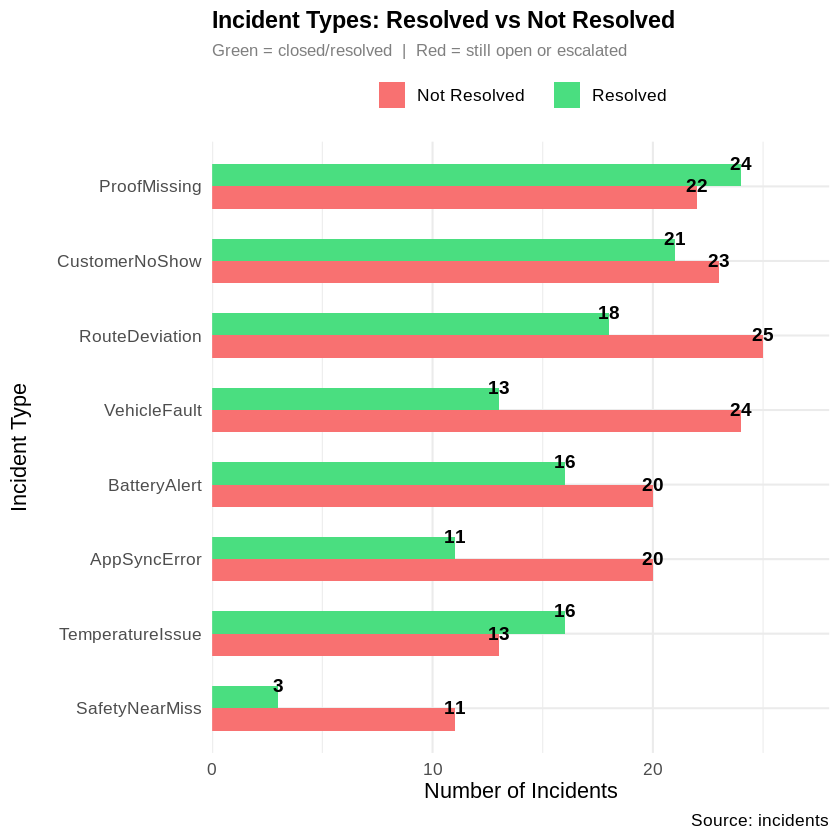

In [24]:
query6 <- sqldf("
  SELECT
    incident_type,
    resolution_status,
    COUNT(*) AS incident_count
  FROM incidents
  GROUP BY incident_type, resolution_status
  ORDER BY incident_count DESC
")

print(query6)

# Simple grouping: Resolved vs Unresolved
query6 <- query6 %>%
  mutate(resolved_group = ifelse(resolution_status %in% c("Closed", "Resolved"),
                                 "Resolved", "Not Resolved"))

summary_q6 <- query6 %>%
  group_by(incident_type, resolved_group) %>%
  summarise(count = sum(incident_count), .groups = "drop")

print(summary_q6)

# Visualization
ggplot(summary_q6,
       aes(x = reorder(incident_type, count, FUN = sum),
           y = count,
           fill = resolved_group)) +
  geom_col(position = "dodge", width = 0.6) +
  geom_text(aes(label = count),
            position = position_dodge(0.6),
            vjust = -0.4, size = 4, fontface = "bold") +
  coord_flip() +
  scale_fill_manual(values = c(
    "Resolved"     = "#4ade80",
    "Not Resolved" = "#f87171"
  )) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(
    title    = "Incident Types: Resolved vs Not Resolved",
    subtitle = "Green = closed/resolved  |  Red = still open or escalated",
    x = "Incident Type",
    y = "Number of Incidents",
    fill = "",
    caption  = "Source: incidents"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title      = element_text(face = "bold", size = 14),
    plot.subtitle   = element_text(colour = "grey50", size = 10),
    legend.position = "top"
  )


QUERY 7 — Compensation Cost by Zone

  pickup_zone complaint_count total_compensation
1     CENTRAL              60            1255.63
2       NORTH              53            1122.69
3        EAST              50            1012.30
4   RIVERSIDE              45             825.08
5       SOUTH              46             767.64
6        WEST              34             729.91
7     AIRPORT              32             444.94


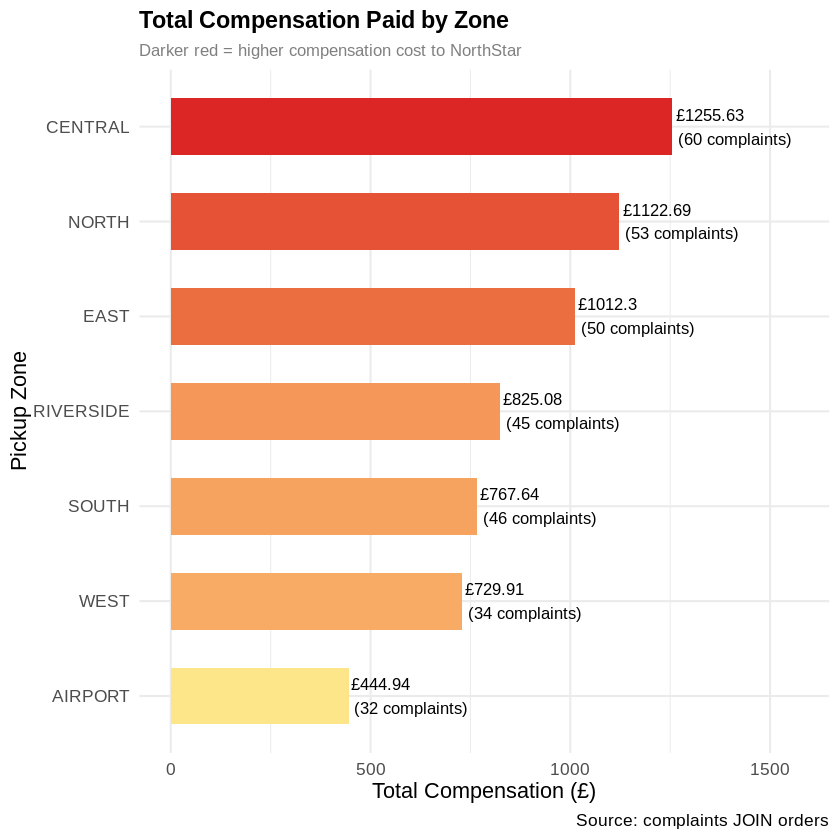

In [26]:
query7 <- sqldf("
  SELECT
    UPPER(TRIM(o.pickup_zone))           AS pickup_zone,
    COUNT(*)                             AS complaint_count,
    ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM complaints c
  JOIN orders o ON c.order_id = o.order_id
  GROUP BY UPPER(TRIM(o.pickup_zone))
  ORDER BY total_compensation DESC
")

print(query7)


# Visualization

ggplot(query7,
       aes(x = reorder(pickup_zone, total_compensation),
           y = total_compensation,
           fill = total_compensation)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = paste0("£", total_compensation,
                               "\n(", complaint_count, " complaints)")),
            hjust = -0.05, size = 3.5) +
  coord_flip(ylim = c(0, max(query7$total_compensation) * 1.25)) +
  scale_fill_gradient(low = "#fde68a", high = "#dc2626") +
  labs(
    title    = "Total Compensation Paid by Zone",
    subtitle = "Darker red = higher compensation cost to NorthStar",
    x = "Pickup Zone",
    y = "Total Compensation (£)",
    caption  = "Source: complaints JOIN orders"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(colour = "grey50", size = 10)
  )